Notebook desarrollado a partir de este notebook disponible en Kaggle
https://www.kaggle.com/moseswmwong/electra-tweets-classifier

## Entrenamiento Modelo

In [1]:
from pathlib import Path
from dotenv import load_dotenv
import os

# Load environment variables from .env file (if present)
env_path = Path.cwd() / '.env'
if env_path.exists():
    load_dotenv(env_path)
    print("Loaded environment variables")

# Verify HF token is available
hf_token = os.getenv('HF_TOKEN')
if not hf_token:
    raise ValueError(
        "HF_TOKEN not found in environment variables. "
        "Please create a .env file with: HF_TOKEN=<your_token>"
    )
print("HF_TOKEN loaded from environment")

Loaded environment variables
HF_TOKEN loaded from environment


In [2]:
# Use HF token from environment (loaded in first cell)
from huggingface_hub import login
login()

In [ ]:
import torch

if torch.cuda.is_available():  
    device = torch.device("cuda")
    print('Will use the GPU:', torch.cuda.get_device_name(0))
    
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

No GPU available, using the CPU instead.


## Cargar y explorar los datos

Se usa el dataset EXIST2021 de la UNED

In [5]:
import pandas as pd
train=pd.read_csv('EXIST2021_dataset/training/EXIST2021_training.tsv', sep='\t')
train=train[train.language == 'es']
train.drop(['test_case', 'id', 'source', 'language'], axis=1, inplace=True)
train['labels']=train['task1'].map({'sexist': 1, 'non-sexist': 0})
train.head()

,text,task1,task2,labels
3436,Nadie te va a tratar tan bien como un hombre q...,sexist,sexual-violence,1
3437,"@lindagisela74 Que rica putita obediente, afor...",sexist,stereotyping-dominance,1
3438,@BicireporteraDF Yo lo hice a los 18 años por ...,non-sexist,non-sexist,0
3439,las cosas q sueño son indicios de que yo enrea...,non-sexist,non-sexist,0
3440,"Pero a la niña le gustó desde que lo vió, así ...",non-sexist,non-sexist,0


In [8]:
train["labels"].value_counts()

labels
0    1800
1    1741
Name: count, dtype: int64

In [9]:
test=pd.read_csv('EXIST2021_dataset/test/EXIST2021_test_labeled.tsv', sep='\t')
test=test[test.language == 'es']
test.drop(['test_case', 'id', 'source', 'language'], axis=1, inplace=True)
test['labels']=test['task1'].map({'sexist': 1, 'non-sexist': 0})
test.head()

,text,task1,task2,labels
2208,Y te golpeo más fuerte perra.,sexist,misogyny-non-sexual-violence,1
2209,@wthxtme @GOLDENMXM Castigado tres meses sin s...,non-sexist,non-sexist,0
2210,@MaricaIndomito jajajaj el me he topado con ta...,sexist,stereotyping-dominance,1
2211,Resulta que hoy es el día de la juventud y no ...,non-sexist,non-sexist,0
2212,@EstefMolina_ Los que dicen que creen en la ig...,sexist,ideological-inequality,1


In [10]:
train = pd.concat([train, test], ignore_index=True)

In [11]:
train["labels"].value_counts()

labels
1    2864
0    2837
Name: count, dtype: int64

In [12]:
train.loc[train.text.str.len()>400]

,text,task1,task2,labels
25,@Noticia_Libre @JulySeEs @AnibelcaRosario @Sus...,non-sexist,non-sexist,0
245,@lunaysol01234 @DINGO40378066 @basi2021 @Karen...,non-sexist,non-sexist,0
784,@anaeugeniavalen @mpcasaretto @alferdez @EliGA...,non-sexist,non-sexist,0
1293,@gisb_sus @mujeresjuezas @no_mas_lagrimas @Mig...,sexist,ideological-inequality,1
2491,@Kylie69996435 @Solarsidol @SenadoArgentina @v...,non-sexist,non-sexist,0
2528,@AcvMatrix @Dan__Vader @Carmatpor @Juan_Acosta...,non-sexist,non-sexist,0
3020,@gloriavdelc @alferdez @laurmachado @SergioLea...,non-sexist,non-sexist,0
3047,@ainhoaeus @BcnInsania @Eritacus @ilusocial @m...,sexist,stereotyping-dominance,1
3371,@OcineTweets @Xmadrid6 @Pau4Mostoles @taxialco...,sexist,stereotyping-dominance,1
3700,Follándose a un perro muerto en frente de los ...,sexist,misogyny-non-sexual-violence,1


In [13]:
import re
def preprocess(text):
    """
    Cleans and normalizes text for NLP model input.
    
    Transformations:
    - Lowercase all text
    - Remove URLs (http/https)
    - Replace HTML entities (&amp;, &lt;, &gt;)
    - Remove mentions (@user)
    - Remove non-ASCII characters
    - Remove punctuation (except . ! ?)
    - Collapse multiple consecutive punctuation to single
    
    Args:
        text (str): Raw input text
    
    Returns:
        str: Cleaned and normalized text
    """
    text=text.lower()
    # remove hyperlinks
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text)
    text = re.sub(r'http?:\/\/.*[\r\n]*', '', text)
    #Replace &amp, &lt, &gt with &,<,> respectively
    text=text.replace(r'&amp;?',r'and')
    text=text.replace(r'&lt;',r'<')
    text=text.replace(r'&gt;',r'>')
    #remove hashtag sign
    #text=re.sub(r"#","",text)   
    #remove mentions
    text = re.sub(r"(?:\@)\w+", '', text)
    #text=re.sub(r"@","",text)
    #remove non ascii chars
    text=text.encode("ascii",errors="ignore").decode()
    #remove some puncts (except . ! ?)
    text=re.sub(r'[:"#$%&\*+,-/:;<=>@\\^_`{|}~]+','',text)
    text=re.sub(r'[!]+','!',text)
    text=re.sub(r'[?]+','?',text)
    text=re.sub(r'[.]+','.',text)
    text=re.sub(r"'","",text)
    text=re.sub(r"\(","",text)
    text=re.sub(r"\)","",text)
    text=" ".join(text.split())
    return text
train['text'] = train['text'].apply(preprocess)
test['text']  =  test['text'].apply(preprocess)

In [14]:
train.head()

,text,task1,task2,labels
0,nadie te va a tratar tan bien como un hombre q...,sexist,sexual-violence,1
1,que rica putita obediente afortunado tu marido...,sexist,stereotyping-dominance,1
2,yo lo hice a los 18 aos por la carretera libre...,non-sexist,non-sexist,0
3,las cosas q sueo son indicios de que yo enreal...,non-sexist,non-sexist,0
4,pero a la nia le gust desde que lo vi as que m...,non-sexist,non-sexist,0


In [15]:
updated_train = train[["text","labels"]]
updated_train.head()

,text,labels
0,nadie te va a tratar tan bien como un hombre q...,1
1,que rica putita obediente afortunado tu marido...,1
2,yo lo hice a los 18 aos por la carretera libre...,0
3,las cosas q sueo son indicios de que yo enreal...,0
4,pero a la nia le gust desde que lo vi as que m...,0


In [16]:
# Get the lists of texts and labels.
texts = updated_train.text.values
labels = updated_train.labels.values

## Tokenizar los tuits

In [17]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from torch.optim import AdamW

model_name = 'pysentimiento/robertuito-hate-speech'
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Force binary single-label setup for this task (sexist vs non-sexist)
config = AutoConfig.from_pretrained(model_name)
config.num_labels = 2
config.problem_type = "single_label_classification"
config.id2label = {0: "non-sexist", 1: "sexist"}
config.label2id = {"non-sexist": 0, "sexist": 1}

# ignore_mismatched_sizes=True reinitializes the classification head to match num_labels=2
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    config=config,
    ignore_mismatched_sizes=True
)
model.to(device)

print("Model configuration check:")
print(f"- num_labels: {model.config.num_labels}")
print(f"- problem_type: {model.config.problem_type}")
print(f"- classifier out_features: {model.classifier.out_proj.out_features}")
print(f"- label2id: {model.config.label2id}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: pysentimiento/robertuito-hate-speech
Key                             | Status     |                                                                                       
--------------------------------+------------+---------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                       
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model configuration check:
- num_labels: 2
- problem_type: single_label_classification
- classifier out_features: 2
- label2id: {'non-sexist': 0, 'sexist': 1}


Token indices sequence length is longer than the specified maximum sequence length for this model (274 > 128). Running this sequence through the model will result in indexing errors


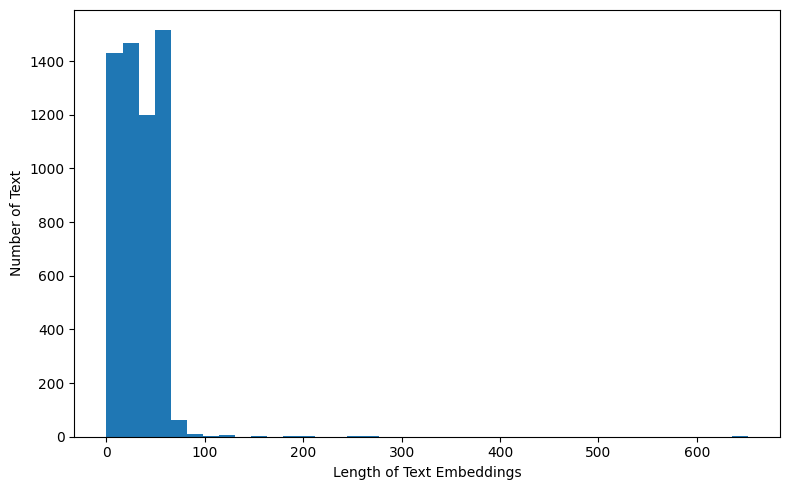

In [18]:
#histogram showing the length of text, text lengths in 40 bins
import matplotlib.pyplot as plt
def plot_sentence_text_length(text_list, tokenizer):
    """
    Visualizes the distribution of tokenized text lengths.
    
    Args:
        text_list: List of text strings to tokenize
        tokenizer: Hugging Face tokenizer
    
    Returns:
        None (displays histogram)
    """
    tokenized_texts = list(map(lambda t: tokenizer.tokenize(t), text_list))
    tokenized_texts_len = list(map(lambda t: len(t), tokenized_texts))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(tokenized_texts_len, bins=40)
    ax.set_xlabel("Length of Text Embeddings")
    ax.set_ylabel("Number of Text")
    plt.tight_layout()  # Prevents label cutoff
    return

plot_sentence_text_length(texts, tokenizer)

In [19]:
# Modernized tokenization: use direct tokenizer call with padding='max_length'
# max_length=100 balances context window with computational cost
indices = tokenizer(
    train['text'].tolist(),
    max_length=100,
    padding='max_length',  # Modern syntax (was: pad_to_max_length=True)
    truncation=True,
    return_attention_mask=True,
    return_tensors=None  # Explicitly return lists, not tensors
)
input_ids = indices["input_ids"]
attention_masks = indices["attention_mask"]

# Data integrity check
assert len(input_ids) == len(labels), "Mismatch: number of tokenized samples != number of labels"
print(f"✓ Tokenization complete: {len(input_ids)} samples tokenized")

✓ Tokenization complete: 5701 samples tokenized


In [20]:
from sklearn.model_selection import train_test_split
# test_size=0.2: Standard 80/20 split for training vs validation (adjust if overfitting occurs)
train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(input_ids, labels, 
                                                            random_state=42, test_size=0.2)
train_masks, validation_masks, _, _ = train_test_split(attention_masks, labels,
                                             random_state=42, test_size=0.2)


In [21]:
# Convert all of our data into torch tensors, the required datatype for our model
train_inputs = torch.tensor(train_inputs)
validation_inputs = torch.tensor(validation_inputs)
train_labels = torch.tensor(train_labels, dtype=torch.long)
validation_labels = torch.tensor(validation_labels, dtype=torch.long)
train_masks = torch.tensor(train_masks, dtype=torch.long)
validation_masks = torch.tensor(validation_masks, dtype=torch.long)

# Data integrity check: verify no data loss in train/val split
total_samples = len(train_inputs) + len(validation_inputs)
assert total_samples == len(input_ids), f"Data loss detected: {len(input_ids)} -> {total_samples}"
print(f"✓ Train/val split: {len(train_inputs)} train, {len(validation_inputs)} validation")

✓ Train/val split: 4560 train, 1141 validation


##Training

In [22]:
#Hyperparameters
# my_learning_rate: Lower than default (5E-5) to prevent overfitting on small dataset
my_learning_rate = 2E-6
# my_adam_epsilon: Standard default value for numerical stability
my_adam_epsilon = 1E-8
# my_number_of_epochs: Training iterations until convergence (adjust based on loss curve)
# my_number_of_epochs = 30
my_number_of_epochs = 1 # Set to 1 for quick testing; increase to 30 for full training
# my_warmup: Linear warmup steps (fraction of total training) to stabilize early training
my_warmup = 3
# my_mini_batch_size: Batch size balancing GPU memory and gradient stability
my_mini_batch_size = 32

In [23]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
batch_size = my_mini_batch_size
# Create the DataLoader for our training set.
train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)
# Create the DataLoader for our validation set.
validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)
validation_sampler = SequentialSampler(validation_data)
validation_dataloader = DataLoader(validation_data, sampler=validation_sampler, batch_size=batch_size)

In [24]:
optimizer = AdamW(model.parameters(),
                  lr = my_learning_rate, #args.learning_rate
                  eps = my_adam_epsilon  #args.adam_epsilon
                )

from transformers import get_linear_schedule_with_warmup
# Number of training epochs
epochs = my_number_of_epochs
# Total number of training steps is number of batches * number of epochs.
total_steps = len(train_dataloader) * epochs
# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps = my_warmup, 
                                            num_training_steps = total_steps)

In [25]:
import numpy as np
#about evalution mert - here we use accuracy, which is good enough because the data is
#is binary classified and distribution is pretty even between positive and negative
#however better evaluation should be use later F1 or AUC ROC because emergency are
#events rare tweets
def flat_accuracy(preds, labels):
    """
    Calculates binary classification accuracy.
    
    Computes simple accuracy (correct predictions / total predictions).
    Note: For imbalanced datasets, consider F1 or AUC-ROC metrics instead.
    
    Args:
        preds (np.ndarray): Logits or confidence scores of shape (n_samples, n_classes)
        labels (np.ndarray): Ground truth labels of shape (n_samples,)
    
    Returns:
        float: Accuracy score in range [0.0, 1.0]
    """
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [26]:
import time
import datetime
def format_time(elapsed):
    """
    Converts elapsed time in seconds to human-readable hh:mm:ss format.
    
    Args:
        elapsed (float): Time in seconds
    
    Returns:
        str: Formatted time string (e.g., "01:23:45")
    """
    # Round to the nearest second.
    elapsed_rounded = int(round((elapsed)))
    
    # Format as hh:mm:ss
    return str(datetime.timedelta(seconds=elapsed_rounded))

In [27]:
import random
# Base on GLUE from huggingface, this is classification problem best suit our problem, here, look at the
# example Python code from hungingface gtihub, here is the here training loop

# This training code is based on the `run_glue.py` script here:
# https://github.com/huggingface/transformers/blob/5bfcd0485ece086ebcbed2d008813037968a9e58/examples/run_glue.py#L128

# Set the seed value all over the place to make this reproducible.
seed_val = 42
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)
# Store the average loss after each epoch so we can plot them.
loss_values = []
# For each epoch...
for epoch_i in range(0, epochs):
    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    # Measure how long the training epoch takes.
    t0 = time.time()

    # Reset the total loss for this epoch.
    total_loss = 0

    model.train()

    for step, batch in enumerate(train_dataloader):

        # Progress update every 100 batches.
        if step % 50 == 0 and not step == 0:
            # Calculate elapsed time in minutes.
            elapsed = format_time(time.time() - t0)
            print('  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))

        # `batch` contains three pytorch tensors: [0]: input ids ,[1]: attention masks,[2]: labels 
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        # Clear any previously calculated gradients.
        # (source: https://stackoverflow.com/questions/48001598/why-do-we-need-to-call-zero-grad-in-pytorch)
        model.zero_grad()        

        # Evaluate the model on this training batch.
        outputs = model(b_input_ids, 
                    token_type_ids=None, 
                    attention_mask=b_input_mask, 
                    labels=b_labels)
        loss = outputs.loss

        # Accumulate the training loss over all of the batches 
        total_loss += loss.item()
        loss.backward()

        # Clip the norm of the gradients to 1.0. to prevent the "exploding gradients" problem.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Update the learning rate.
        scheduler.step()

    # Calculate the average loss over the training data.
    avg_train_loss = total_loss / len(train_dataloader)            
    
    # Store the loss value for plotting the learning curve.
    loss_values.append(avg_train_loss)

    print("")
    print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training epoch took: {:}".format(format_time(time.time() - t0)))
      
print("")
print("Training complete!")


======== Epoch 1 / 1 ========
Training...
  Batch    50  of    143.    Elapsed: 0:19:53.
  Batch   100  of    143.    Elapsed: 0:36:16.

  Average training loss: 0.65
  Training epoch took: 0:50:52

Training complete!


In [28]:
# Create output directory and save model locally
model_output_path = Path("./model_output")
model_output_path.mkdir(parents=True, exist_ok=True)

tokenizer.save_pretrained(str(model_output_path))
model.save_pretrained(str(model_output_path))
print(f"✓ Model and tokenizer saved to {model_output_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model and tokenizer saved to model_output


##Validation

In [29]:
# Validation
print("")
print("Running Validation...")

t0 = time.time()
model.eval()

preds=[]
true=[]

# Tracking variables 
eval_loss, eval_accuracy = 0, 0
nb_eval_steps, nb_eval_examples = 0, 0

# Evaluate data for one epoch
for batch in validation_dataloader:
    
    # Add batch to GPU
    batch = tuple(t.to(device) for t in batch)
    
    # Unpack the inputs from our dataloader
    b_input_ids, b_input_mask, b_labels = batch
    
    # Telling the model not to compute or store gradients, saving memory and speeding up validation
    with torch.no_grad():        

        outputs = model(b_input_ids, 
                        token_type_ids=None, 
                        attention_mask=b_input_mask)
    
    logits = outputs.logits

    # Move logits and labels to CPU
    logits = logits.detach().cpu().numpy()
    label_ids = b_labels.to('cpu').numpy()
    
    preds.append(logits)
    true.append(label_ids)
    # Calculate the accuracy for this batch.
    tmp_eval_accuracy = flat_accuracy(logits, label_ids)
    
    # Accumulate the total accuracy.
    eval_accuracy += tmp_eval_accuracy

    # Track the number of batches
    nb_eval_steps += 1

# Report the final accuracy for this validation run.
print("  Accuracy: {0:.2f}".format(eval_accuracy/nb_eval_steps))
print("  Validation took: {:}".format(format_time(time.time() - t0)))


Running Validation...
  Accuracy: 0.71
  Validation took: 0:03:40


In [30]:
# Combine the predictions for each batch into a single list of 0s and 1s.
flat_predictions = [item for sublist in preds for item in sublist]
flat_predictions = np.argmax(flat_predictions, axis=1).flatten()
# Combine the correct labels for each batch into a single list.
flat_true_labels = [item for sublist in true for item in sublist]

In [31]:
from sklearn.metrics import classification_report
print(classification_report(flat_predictions,flat_true_labels))

              precision    recall  f1-score   support

           0       0.66      0.73      0.70       518
           1       0.76      0.69      0.72       623

    accuracy                           0.71      1141
   macro avg       0.71      0.71      0.71      1141
weighted avg       0.71      0.71      0.71      1141



Ursprüngliche Ergebnisse (mit vollem Trainingsverlauf):

In [ ]:
# from sklearn.metrics import classification_report
# print(classification_report(flat_predictions,flat_true_labels))

              precision    recall  f1-score   support

           0       0.74      0.82      0.78       524
           1       0.83      0.76      0.79       617

    accuracy                           0.79      1141
   macro avg       0.79      0.79      0.79      1141
weighted avg       0.79      0.79      0.79      1141

